In [2]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from fit_funcs import *
import costfun.costfun as cost
import utils.figures as fig_help
from RandomMatrixTheory import goe, gue
from Quad_tools import *
import entropy as ent

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import gamma as Gamma
from scipy.special import lambertw
from scipy.special import dawsn as dawson
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
 
# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists

DIM = 1
modello = 'RP'


def base_dir(model, d, ensemble = 'GOE', BC = 0):
    """
    Base directory for input model for d-dimension
    """
    dirx = f"../results/{model}/" + (ensemble + f"/" if model == 'PLRB' or model == 'RP' or model == 'SYK2' else  f"dim={d}/") + ( '' if model == 'RP' or model == 'SYK2' else (f"PBC/" if BC else f"OBC/") )
    return dirx

def base_dir_old(model, d, BC = 0):
    """
    Base directory for input model for d-dimension
    """
    dirx = f"../results/{model}/" + (f"" if model == 'PLRB' or model == 'RP' else  f"dim={d}/") + ( '' if model == 'RP' else (f"PBC/" if BC else f"OBC/") )
    return dirx

print(base_dir(modello, DIM))

%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

/Users/rafal.swietek/Projects/CODES/QHamSolver/Quadratic/Jupyter_Python
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../Python/
../results/RP/GOE/


## FRACTAL DIMENSION

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


../results/RP/GOE/NewBasis/ParticipationRatio/_L=15,J=1,g=0.4.hdf5
../results/RP/GOE/NewBasis/ParticipationRatio/_L=15,J=1,g=0.8.hdf5
../results/RP/GOE/NewBasis/ParticipationRatio/_L=15,J=1,g=1.hdf5
../results/RP/GOE/NewBasis/ParticipationRatio/_L=15,J=1,g=1.2.hdf5


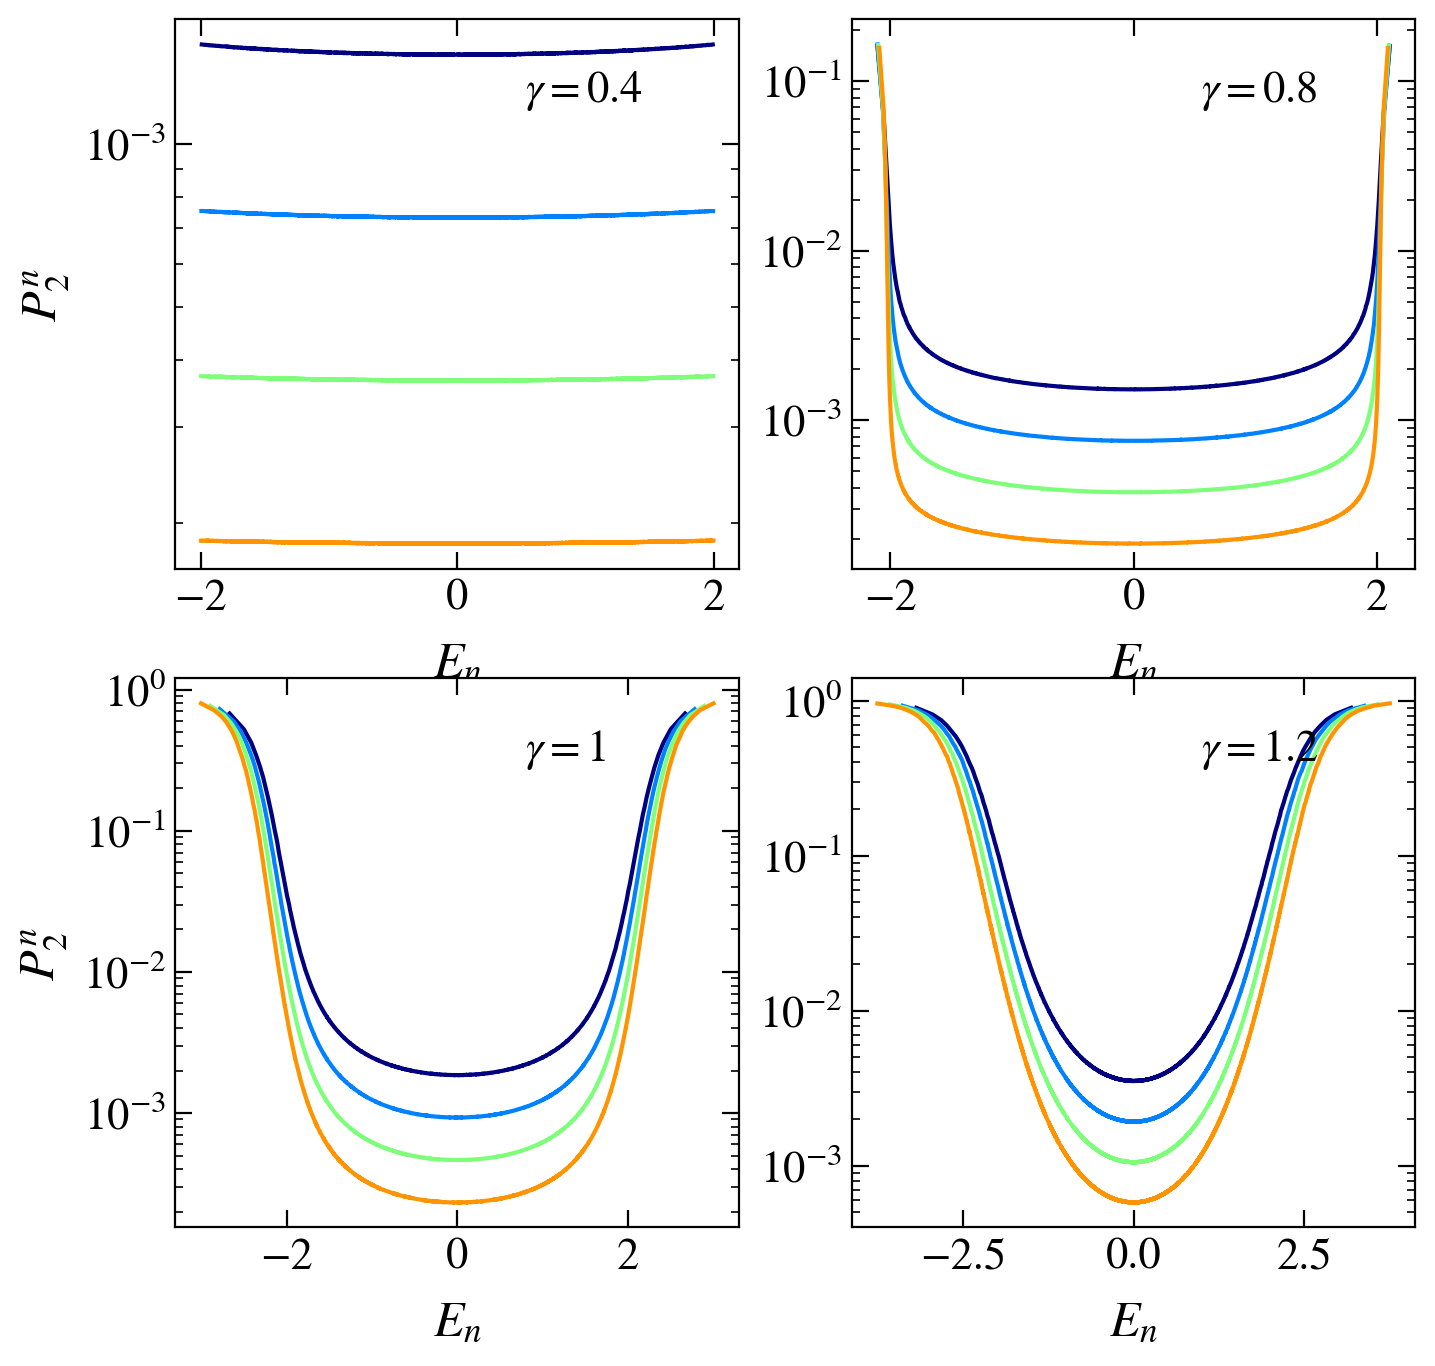

In [2]:
colors_ls_cyc = itertools.cycle(colors_ls)
from matplotlib.ticker import MaxNLocator

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM)

sizes = np.arange(11, 16, 1)
gammas = np.arange(0., 4.91, 0.2)

DIM = 1

gamma_vals = [0.4, 0.8, 1.0, 1.2]

fig, axis = plt.subplots( nrows=2, ncols=2, figsize=(8, 8), dpi = 200)#, sharex=True)
axis = axis.flatten()

qs = [0.5, 1.0, 1.5, 2, 3.0]

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])
for ii, gx in enumerate(gamma_vals):
    for L in sizes:
        dim = 2**L
        col = s_m.to_rgba(L)
        name = prefix + 'NewBasis/ParticipationRatio/' + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        if exists(name):
            with h5py.File(name, "r") as file:
                    energies = np.array(file.get('mean energies'))
                    
                    pr = np.array(file.get('Pr'))# * 2**(3*L_total)
                    Sinfo = np.array(file.get('InfoPr'))
                    axis[ii].plot(energies / np.sqrt(1 + dim**(1-gx)), pr, color=col)
        else:
            print(name)
            
    fig_help.set_plot_elements(axis[ii], ylabel=r"$P_2^n$" if ii%2 == 0 else "", xlabel=r"$E_n$", font_size=16, set_legend=1, xscale='linear', yscale='log')
    axis[ii].annotate(r" $\gamma=%g$"%gx, fontsize=16, xy=(0.6, 0.85), xycoords='axes fraction')

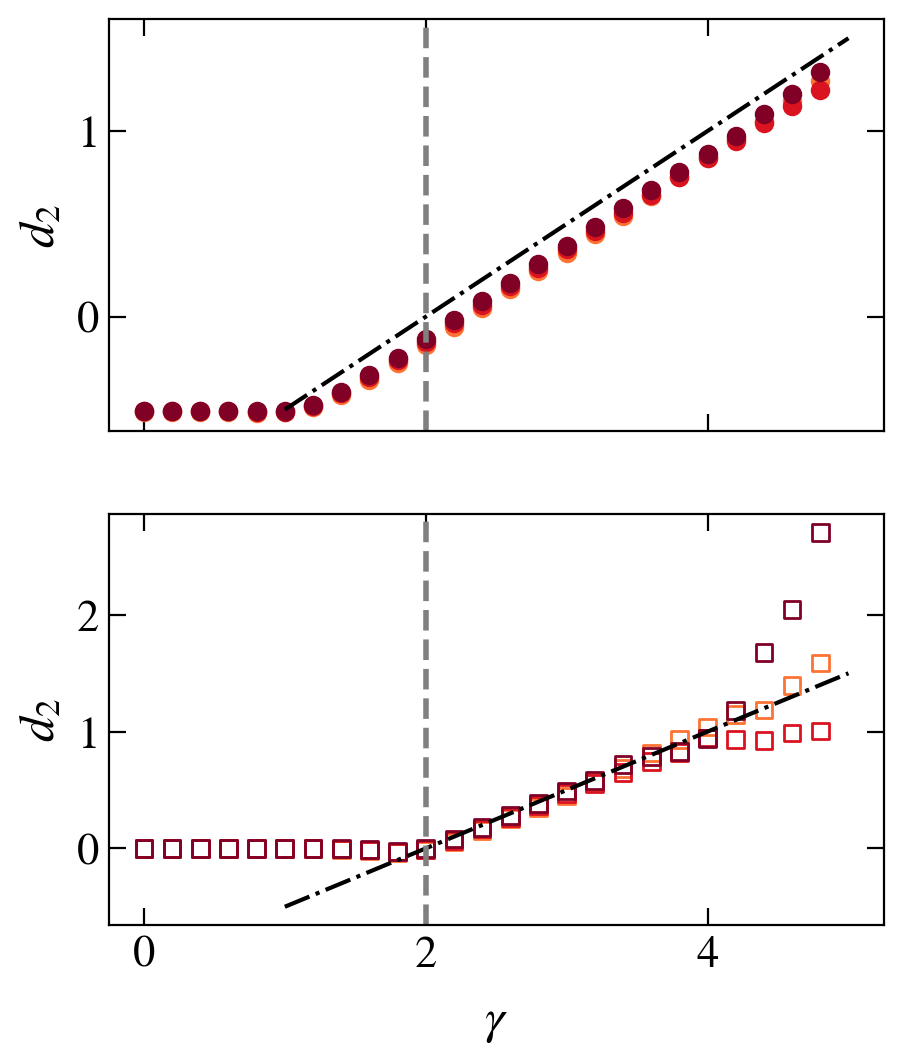

In [182]:
colors_ls_cyc = itertools.cycle(colors_ls)
from matplotlib.ticker import MaxNLocator

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM)

sizes = np.arange(11, 15, 1)
gammas = np.arange(0., 4.91, 0.2)

DIM = 1

def lorenz(x, A, sig, G):
    return A / G / np.pi / ( (x / G)**2 + 1) * np.exp(-x**2 / (2*sig**2) ) /np.sqrt(2*np.pi*sig**2)
    # return A / np.sqrt(2*np.pi*sig**2) * np.exp(-x**2 / (2*sig**2))


L = 15
eps = 0.5
gamma_c = 2


sizes = np.arange(10, 15, 1)
norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes) )


# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])

fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(5, 6), dpi = 200, sharex=True)


iddx1 = 0
iddx2 = -2
qs = [0.5, 1.0, 1.5, 2, 3.0]
q1 = qs[iddx1]
q2 = qs[iddx2]


def _fun_pr(L, a, d2):
    return a * 2**(-d2 * sizes)

def _fun_info(L, a, d2):
    return -d2 * L + a

d2 = np.zeros( (gammas.size, sizes.size-2))
d2_comp = np.zeros( (gammas.size, sizes.size-2) )
for ii, gx in enumerate(gammas):
    
    pr       = np.zeros((sizes.size));                  pr.fill(np.nan)
    Sinfo    = np.zeros((sizes.size));                  Sinfo.fill(np.nan)
    pr_comp       = np.zeros((sizes.size));             pr_comp.fill(np.nan)
    Sinfo_comp    = np.zeros((sizes.size));             Sinfo_comp.fill(np.nan)
    
    dims = 2**sizes
    for iiL, L in enumerate(sizes):
        col = s_m.to_rgba(L)
        dim = 2**L
        name = prefix + 'NewBasis/ParticipationRatio/' + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        
        if exists(name):
            with h5py.File(name, "r") as file:
                E = np.array(file.get('mean energies'))
                idxE = np.argmin(np.abs(E))
                num = int( min(500, 0.1*dim) )
                # print(idxE, idxE - num//2, idxE + num//2)
                pr[iiL] = np.mean(np.array(file.get('Pr_q'))[iddx1]) - 1
                Sinfo[iiL] = np.mean(np.array(file.get('InfoPr_q'))[iddx1])
                
                pr_comp[iiL] = 1 - np.mean(np.array(file.get('Pr_q'))[iddx2])
                Sinfo_comp[iiL] = np.mean(np.array(file.get('InfoPr_q'))[iddx2])
        else:
            print(name)
    
    X = -np.diff(np.log(pr)) / np.diff(np.log(dims))
    X = (X[1:] + X[:-1]) / 2
    d2[ii, :] = X# / (q1 - 1)
    X = -np.diff(np.log(pr_comp)) / np.diff(np.log(dims))
    X = (X[1:] + X[:-1]) / 2
    d2_comp[ii, :] = X# / (q2 - 1)
    

for iiL, L_total in enumerate(sizes[1:-1]):
    col = s_m.to_rgba(L_total+1)
    axis[0].scatter(gammas, d2[:,iiL], color=col)
    axis[1].scatter(gammas, d2_comp[:, iiL], color=col, marker='s', facecolor='None')

x = np.linspace(1, 5, 1000)
# axis[0].plot(x, (q1 * x - 1) / (q1 - 1), ls='-.', color='k')
axis[0].plot(x, x/2-1, ls='-.', color='k')
axis[1].plot(x, x/2-1, ls='-.', color='k')

axis[0].axvline(x=gamma_c, ls='--', color='gray', lw=2)
axis[1].axvline(x=gamma_c, ls='--', color='gray', lw=2)

fig_help.set_plot_elements(axis[0], ylabel=r"$d_2$", xlabel=r"", font_size=16, set_legend=0, xscale='linear', yscale='linear')
fig_help.set_plot_elements(axis[1], ylabel=r"$d_2$", xlabel=r"$\gamma$", font_size=16, set_legend=0, xscale='linear', yscale='linear')
# fig_help.set_plot_elements(axis[2], ylabel=r"$d_2$", xlabel=r"$\alpha$", font_size=16, set_legend=1, xscale='linear', yscale='linear')

../results/RP/SpectralFunctions/_L=16,J=1,g=0.hdf5
../results/RP/SpectralFunctions/_L=16,J=1,g=0.1.hdf5
../results/RP/SpectralFunctions/_L=16,J=1,g=0.2.hdf5
../results/RP/SpectralFunctions/_L=16,J=1,g=0.3.hdf5
../results/RP/SpectralFunctions/_L=16,J=1,g=0.4.hdf5


No handles with labels found to put in legend.


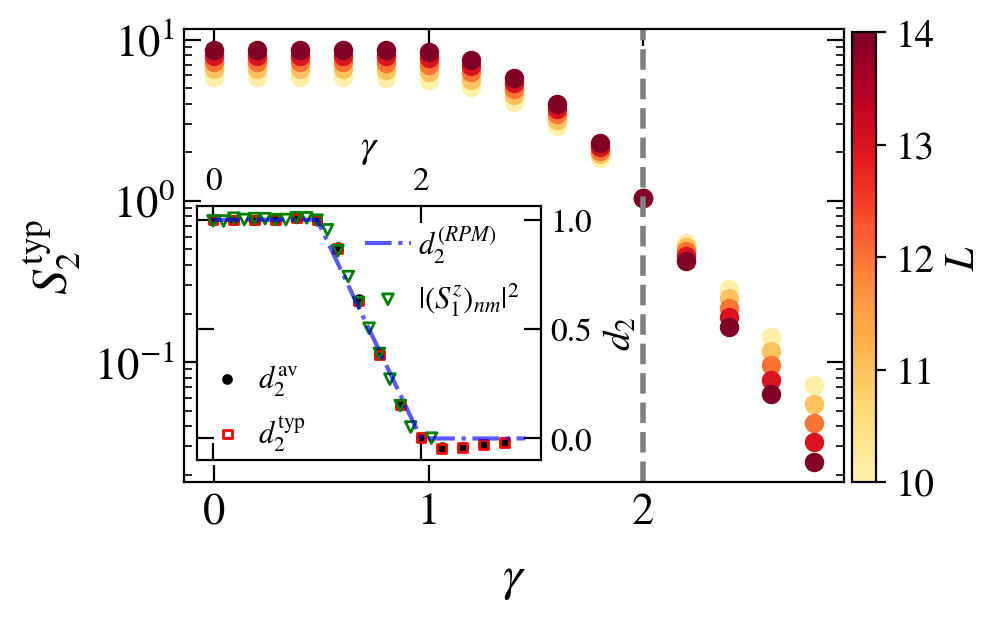

In [4]:
colors_ls_cyc = itertools.cycle(colors_ls)
from matplotlib.ticker import MaxNLocator

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM)

sizes = np.arange(11, 15, 1)
gammas = np.arange(0.0, 2.91, 0.2)

DIM = 1

def lorenz(x, A, sig, G):
    return A / G / np.pi / ( (x / G)**2 + 1) * np.exp(-x**2 / (2*sig**2) ) /np.sqrt(2*np.pi*sig**2)
    # return A / np.sqrt(2*np.pi*sig**2) * np.exp(-x**2 / (2*sig**2))


L = 15
eps = 0.5
gamma_c = 2


sizes = np.arange(10, 15, 1)
norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes) )


# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4, 3), dpi = 200, sharex=True)
inset = axis.inset_axes([0.02, 0.05, 0.52, 0.56])

iddx = -2
qs = [0.5, 1.0, 1.5, 2, 3.0]
q = qs[iddx]

pr_all = []
Sinfo_all = []
for L in sizes:
    col = s_m.to_rgba(L)
    dim = 2**L
    
    pr       = np.zeros((gammas.size));                  pr.fill(np.nan)
    Sinfo    = np.zeros((gammas.size));                  Sinfo.fill(np.nan)
    pr_comp       = np.zeros((gammas.size));             #pr_comp.fill(np.nan)
    Sinfo_comp    = np.zeros((gammas.size));             #Sinfo_comp.fill(np.nan)
    for ii, gx in enumerate(gammas):
        name = prefix + 'NewBasis/ParticipationRatio/' + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        
        if exists(name):
            with h5py.File(name, "r") as file:
                E = np.array(file.get('mean energies'))
                dE = np.mean(np.array(file.get('dE')))
                E0 = np.mean(np.array(file.get('E0')))
                
                Etarget = np.mean(E)
                Etarget = E0 + dE * 1/2
                
                idxE = np.argmin(np.abs(E - Etarget))
                num = int( min(500, 0.1*dim) )
                idx_min = idxE - num//2;
                if idx_min < 0: idx_min = 0
                idx_max = idxE + num//2
                if idx_max > dim-1: idx_max = dim
                # print(idxE, idxE - num//2, idxE + num//2)
                # pr[ii] = np.mean(np.array(file.get('Pr_q'))[iddx])
                pr[ii] = np.mean(np.array(file.get('Pr'))[idx_min : idx_max])
                Sinfo[ii] = np.mean(np.array(file.get('InfoPr'))[idx_min : idx_max])
                # Sinfo[ii] = np.mean(np.array(file.get('InfoPr_q'))[iddx])
        else:
            print(name)
            
    # axis[0].scatter(gammas, pr, color=col)
    axis.scatter(gammas, Sinfo, color=col)
    pr_all.append(pr)
    Sinfo_all.append(Sinfo)

pr_all = np.transpose(np.array(pr_all))
Sinfo_all = np.transpose(np.array(Sinfo_all))

dims = 2**sizes
d2 = np.zeros(gammas.shape)
d2_loc = np.zeros(gammas.shape)
d2_typ = np.zeros(gammas.shape)

def _fun_pr(L, a, d2):
    return a * 2**(-d2 * L)

def _fun_info(L, a, d2):
    return d2 * L + a

for ii, gx in enumerate(gammas):
    _pr_ = pr_all[ii]
    _info_ = Sinfo_all[ii]
    a1 = -(np.log(_pr_[-1]) - np.log(_pr_[-2])) / (np.log(dims[-1]) - np.log(dims[-2])) / (q - 1)
    # a2 = -(np.log(_pr_[-2]) - np.log(_pr_[-3])) / (np.log(dims[-2]) - np.log(dims[-3])) / (q - 1)
    d2[ii] = a1#(a1 + a2) / 2
    # _pr_ = Sinfo_all[ii][-1] - Sinfo_all[ii][-2]
    # d2[ii] = (Sinfo_all[ii][0] - 4 * Sinfo_all[ii][1] + 3 * Sinfo_all[ii][2]) / 2# * 1 / (1 - q)
    pars, pconv= fit(_fun_pr,
                    xdata = sizes,
                    ydata = _pr_,
                    maxfev = 20000)
    d2[ii] = (pars[-1]) / (q-1)
    pars, pconv= fit(_fun_pr,
                    xdata = sizes,
                    ydata = 1-_pr_,
                    maxfev = 20000)
    d2_loc[ii] = (pars[-1]) / (q-1)
    
    pars2, pconv2 = fit(_fun_info,
                    xdata = sizes,
                    ydata = _info_,
                    maxfev = 20000)
    d2_typ[ii] = (pars2[-1]) / np.log(2)
    

# print(d2)
_handles_ = []
line = inset.scatter(gammas, d2, color='k', label=r"$d_{%d}^{\rm av}$"%q, s=8); _handles_.append(line)
# axis[2].scatter(gammas, d2_loc, color='green', marker='v', facecolor='None', label=r"$\tilde{d}^{(%d)}_{\rm av}$"%q)    
line = inset.scatter(gammas, d2_typ, color='red', marker='s', facecolor='None', label=r"$d_{%d}^{\rm typ}$"%q, s=10); _handles_.append(line)

x = np.linspace(0, 3, 1000)
line, = inset.plot(x, np.heaviside(1-x, 1) + (2-x) * (np.heaviside(2-x, 0) + np.heaviside(x-1, 0) - 1), ls='-.', color='blue', alpha=0.65, label=r"$d_2^{(RPM)}$"); _handles_.append(line)

axis.axvline(x=gamma_c, ls='--', color='gray', lw=2)
inset.xaxis.set_ticks_position('top')
inset.xaxis.set_label_position('top')
inset.yaxis.set_ticks_position('right')
inset.yaxis.set_label_position('right')


def matelem_fit(DOS, a0, eta):
    return a0 * DOS**(-1 / eta)

AGP = 0


sizes = np.arange(8, 17, 1)
omegax = np.zeros( (20 * (L)) )
_gamma_ = np.arange(0.0, 2.11, 0.1)

eps = 0.5
colors = []
eta_eps = []
for gx in _gamma_:
    # if 
    col = s_m.to_rgba(gx)
    colors.append(col)
    
    all_spec = []
    all_spec_typ = []
    cut = 0
    
    wH = np.zeros(sizes.shape)
    spec_at_wH_G = np.zeros(sizes.shape);   spec_at_wH_G.fill(np.nan);
    
    DOS = np.zeros(sizes.shape)
    for iiL, L in enumerate(sizes):
        dim = 2**L
        name = '../results/RP/SpectralFunctions/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        if exists(name):
            with h5py.File(name, "r") as file:
                R = np.array(file.get('realisations'))
                
                Ex = np.array(file.get('energy_density'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                
                X = np.array(file.get('wH_typ_density'))[idx]
                _DOS = np.array(file.get('DOS'))
                _DOS = _DOS[idx] / max(_DOS) * dim
                
                # print(eps, idx, _DOS)
                DOS[iiL] = _DOS#dim#_DOS#1/X
                
                wH[iiL] = X
                cut = X / 5
            
                R = np.array(file.get('realisations'))
                # print(L, alfa, R)
                omegax = np.array(file.get('omegas'))
                omegax = np.sqrt(omegax[1:] * omegax[:-1])
                spec_fun = np.array(file.get('spec_fun'))[idx]
                spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx]
                        
                yy0 = spec_fun if AGP else spec_fun_typ
                
                omegax = omegax[~np.isnan(yy0)]
                spec_fun = spec_fun[~np.isnan(yy0)]
                spec_fun_typ = spec_fun_typ[~np.isnan(yy0)]
                yy0 = yy0[~np.isnan(yy0)]
                indices = np.where(np.logical_and(omegax >= cut, omegax < 1))[0]
                
                xx = omegax#[indices]
                yy = yy0#[indices]
                yy = integrate.cumulative_trapezoid(yy, xx)
                yy = (yy - yy[0]) / (yy[-1] - yy[0])
                G = xx[np.argmin( np.abs(yy - 0.5) )]
                # Gamma[iiL] = G
                
                idx_spec1 = min(range(len(omegax)), key=lambda i: abs(omegax[i] - wH[iiL]))
                spec_at_wH_G[iiL] = np.sqrt( np.mean(spec_fun[idx_spec1 - 20 : idx_spec1 + 20]) )
        else:
            print(name)
    DOS = DOS[~np.isnan(spec_at_wH_G)]
    spec_at_wH_G = spec_at_wH_G[~np.isnan(spec_at_wH_G)]
    
    pars, pconv= fit(matelem_fit,
                xdata = DOS[-5:],
                ydata = spec_at_wH_G[-5:],
                maxfev = 20000)
    _etaX = np.abs(pars[-1])
    if _etaX > 1e7 or _etaX < 0: 
        _etaX = np.nan
    else:
        zz = np.linspace(min(DOS), max(DOS), 5000)
        # axis2[0].plot(zz, matelem_fit(zz, *pars), ls='--', color=col)
    eta_eps.append(_etaX)
    

eta_eps = np.array(eta_eps)
line = inset.scatter(_gamma_, 2/eta_eps, color='green', marker='v', facecolor='None', label=r"$|(S^z_1)_{nm}|^2$", s=15)
_handles_.append(line)

# fig_help.set_plot_elements(axis[0], ylabel=r"$P_2$", xlabel=r"", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis, ylabel=r"$S^{\rm typ}_2$", xlabel=r"$\gamma$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(inset, ylabel=r"$d_2$", xlabel=r"$\gamma$", font_size=12, set_legend=1, xscale='linear', yscale='linear')
leg = fig_help.set_legend(inset, fontsize=11, loc='lower left', anchor=(-0.06, -0.08), ncol=1, handles=_handles_[:2])
fig_help.set_legend(inset, fontsize=11, loc='upper right', anchor=(1.02, 1.04), ncol=1, handles=_handles_[2:])
fig.add_artist(leg)

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.125, 0.03, 0.75])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation='vertical')
cbar.set_label(r"$L$", fontsize=15)
cbar.ax.tick_params(labelsize=14)

fig.subplots_adjust(wspace = 0.03, hspace=0.03)

fig.savefig("PLOTS_FADING/BEYOND_RMT/Fig_d2_RP.pdf", bbox_inches = 'tight', pad_inches=0.02)

## LDOS

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


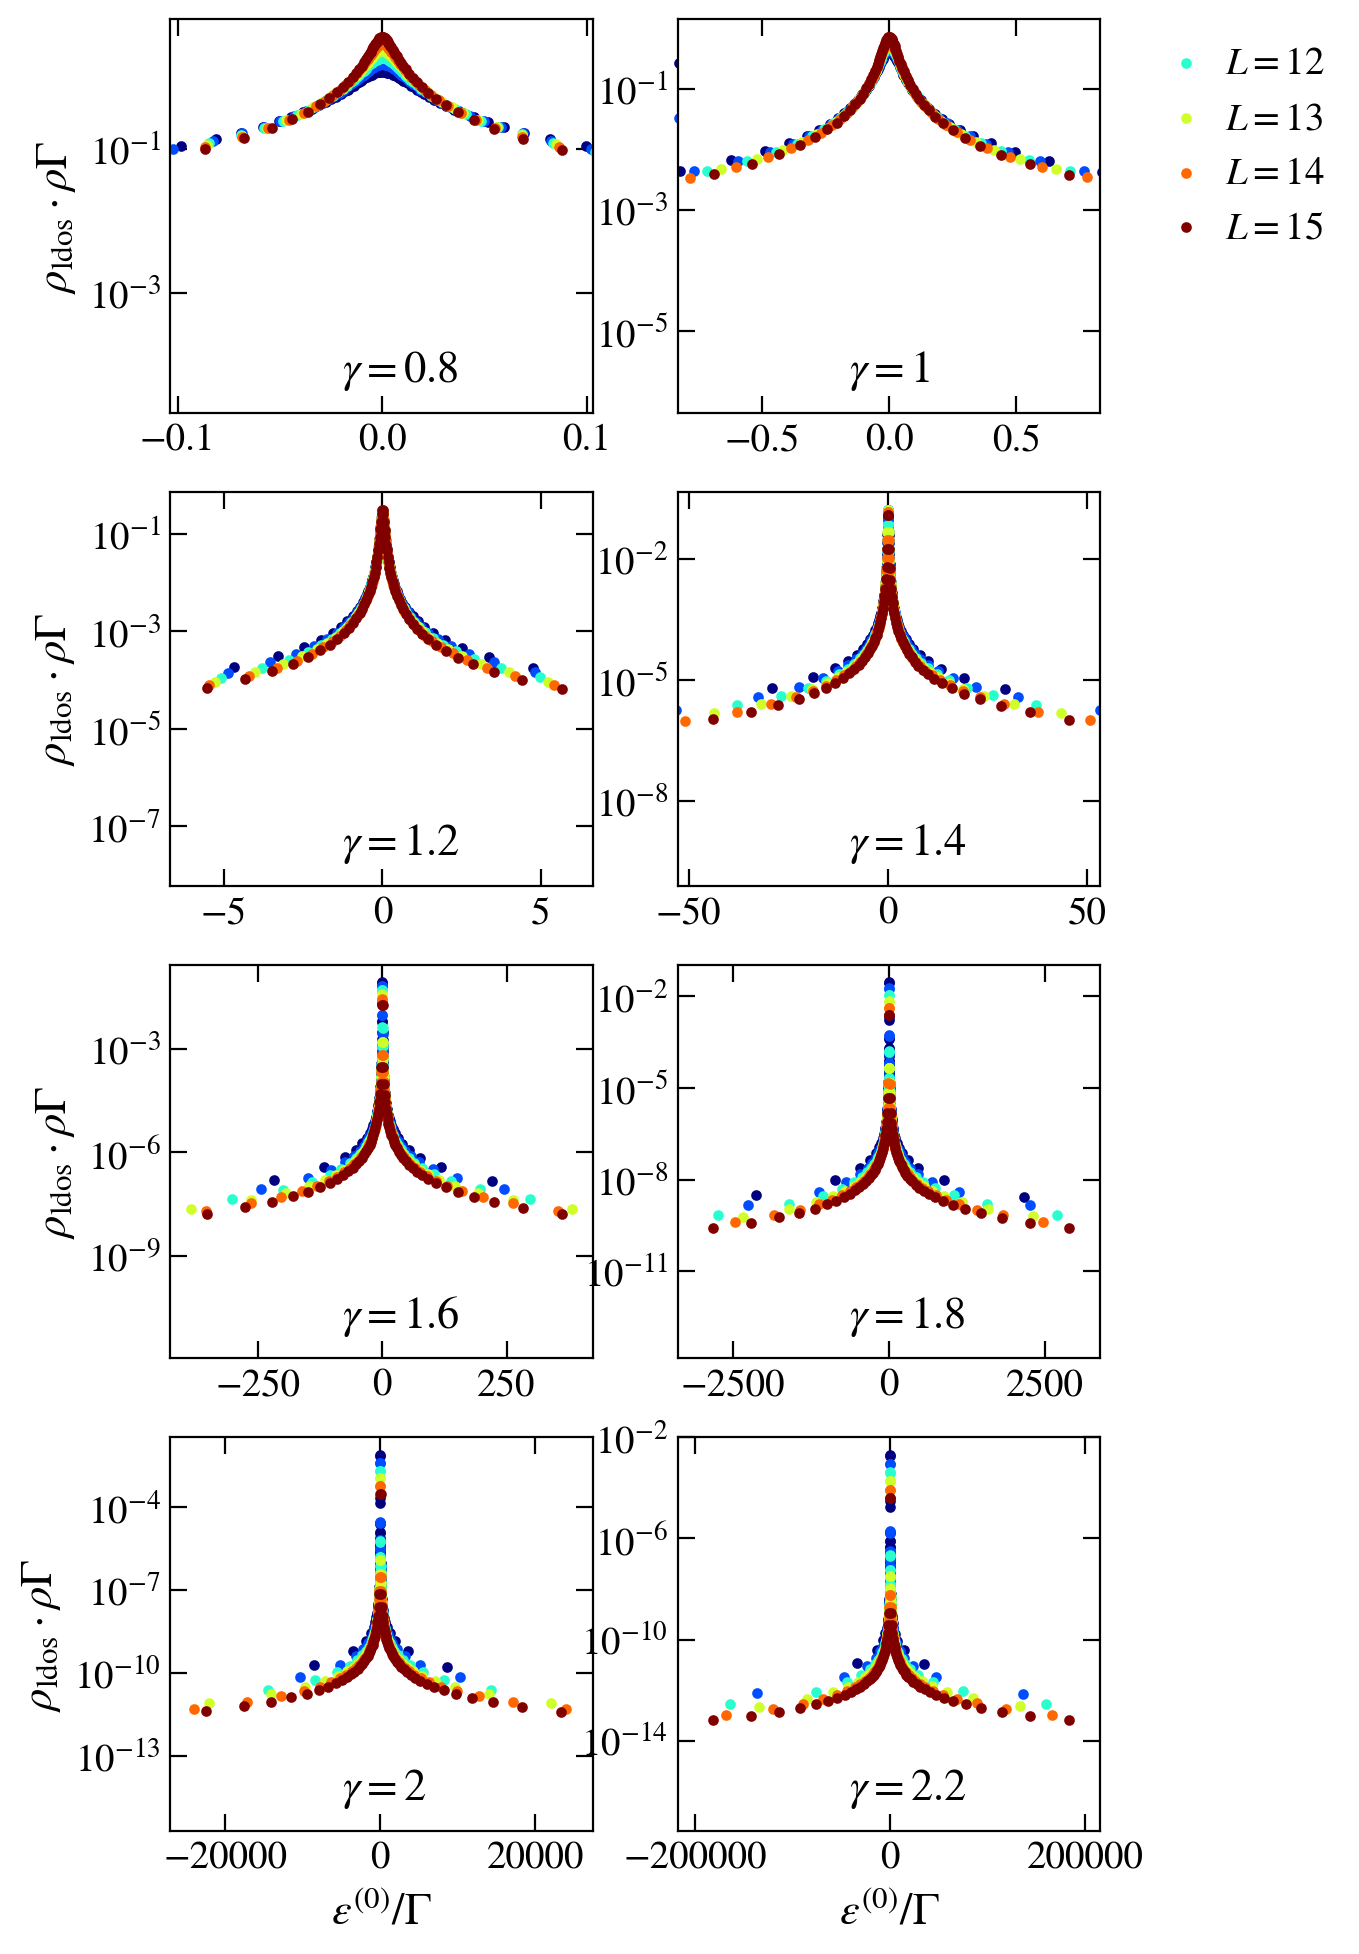

In [10]:
colors_ls_cyc = itertools.cycle(colors_ls)
from matplotlib.ticker import MaxNLocator

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM)

sizes = np.arange(10, 16, 1)

DIM = 1
fig, axis = plt.subplots( nrows=4, ncols=2, figsize=(6,12), dpi = 200, sharex=False, sharey=False)
axis = axis.flatten()

def lorenz(x, A, sig, G):
    return A / G / np.pi / ( (x / G)**2 + 1) * np.exp(-x**2 / (2*sig**2) ) /np.sqrt(2*np.pi*sig**2)
    # return A / np.sqrt(2*np.pi*sig**2) * np.exp(-x**2 / (2*sig**2))

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])


L = 15
eps = 0.5
gamma_c = 2


gx = 1.2

dim = 2**L

gammas = np.arange(0.8, 2.31, 0.2)

for iig, gx in enumerate(gammas):
    for ii, L in enumerate(sizes):
        dim = 2**L   
        col = s_m.to_rgba(L)
        num = min([100, dim//50])
        name = prefix + 'NewBasis/ParticipationRatio/' + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        if exists(name):
            with h5py.File(name, "r") as file:
                dE = np.mean(np.array(file.get('dE')))
                E0 = np.mean(np.array(file.get('E0')))
                energy_density = np.array(file.get('energy_density'))
                energy_density = (energy_density[1:] + energy_density[:-1]) / 2.
                # energy_density = -2*(energy_density-0.5)
                # energy_density = 2*(0.5 - energy_density)
                energy_density = ( (energy_density) * dE + E0)
                # energy_density = (E0 + dE/2) - ( (energy_density) * dE + E0)
                # ldos = np.exp( np.mean(np.log(np.array(file.get('LDOS'))), axis=1) )
                ldos = ( np.mean((np.array(file.get('LDOS'))), axis=1) )
                # ldos = np.array(file.get('LDOS'))[:,num//2]
                # print(L, gx, np.sum(ldos))
                
                sig = np.sqrt(1 + dim**(1.0-gx))
                # DOS = dim / np.sqrt(2*np.pi*sig**2) * np.exp(-energy_density**2 / (2*sig**2))
                # DOS = DOS + DOS * 4 * dim**(2-gx) / sig**2 * (2*np.sqrt(2) * energy_density / sig * dawson(energy_density / np.sqrt(2) / sig) - 1)
                DOS = np.array(file.get('DOS0'))
                HSnorm = dim+1
                G = 2 * np.pi * dim**(-gx) * HSnorm * DOS / (dim - 1.0)# if gx >= 1 else DOS * sig * HSnorm
                
                xx = energy_density / G# * np.sqrt(dim)
                yy = ldos  * G# * DOS# / dim# / G
                
                if iig == 0 and ii < 2: axis[iig].scatter( xx, yy, color=col, label=r"$L=%d$"%L, s=8)
                elif iig == 1 and ii > 1: axis[iig].scatter( xx, yy, color=col, label=r"$L=%d$"%L, s=8)
                else:                     axis[iig].scatter( xx, yy, color=col, s=8)
                # energy_density = np.array(file.get('energy_density2'))
                # energy_density = (energy_density[1:] + energy_density[:-1]) / 2.
                # # energy_density = -2*(energy_density-0.5)
                # energy_density = 2*(0.5 - energy_density)
                # # energy_density = -(energy_density * dE + E0)
                # # ldos = np.exp( np.mean(np.log(np.array(file.get('LDOS2'))), axis=1) )
                # ldos = ( np.mean((np.array(file.get('LDOS2'))), axis=1) )
                # axis.plot( energy_density, ldos, color=col, label=r"$L=%d$"%L_total)
                
                # pars, pconv= fit(lorenz,
                #         xdata = xx,
                #         ydata = yy,
                #         maxfev = 20000)
                
                # # print("A=", pars[0], "G=", pars[-1], "sig/sig_pred=", pars[-2] / np.sqrt(1 + dim**(1-gx)))
                # z = np.linspace(min(xx), max(xx), 1000)
                
                # # sig = np.sqrt(1 + dim**(1-gx))
                # # DOS = dim / np.sqrt(2*np.pi*sig**2) * np.exp(-z**2 / (2*sig**2))
                # # G = np.pi * dim**(-gx) * DOS
                # axis[iig].plot(z, lorenz(z, *pars), color=col, ls='--', lw=2, alpha=0.6)
                # axis[iig].set_ylim(min(yy), max(yy))
        else:
            print(name)
        

    # z = np.linspace(min(xx), max(xx), 100000)
    # G = 1#0.05
    # yy = G / 80 / ( z**2 + G**2)
    # axis[iig].plot(z, yy, ls='--', color='k', lw=2, alpha=0.6, label=r"$\frac{A}{(\omega)^2+1}$")
    # axis.plot(np.nan, np.nan, ls='--', color='k', label=r"$\frac{A}{(\omega/\Gamma)^2+1}e^{-\frac{E^2}{(2\sigma^2)}}$")
    axis[iig].annotate(r" $\gamma=%g$"%gx, fontsize=16, xy=(0.38, 0.08), xycoords='axes fraction')
    fig_help.set_plot_elements(axis[iig], ylabel=r"$\rho_{\rm ldos}\cdot\rho\Gamma$" if iig%2==0 else "", xlabel=r"$\epsilon^{(0)}/\Gamma$" if iig > len(axis)-3 else "", font_size=14, set_legend=1, xscale='linear', yscale='log')
    fig_help.set_legend(axis[iig], fontsize=14, loc='upper left', anchor=(1.05, 1.02), ncol=1)
    axis[iig].set_xlim(min(xx)/150, max(xx)/150)
    # axis[iig].set_xscale('symlog', linthresh=10)# `linthresh` controls the linear region near zero
    # axis[iig].xaxis.set_minor_locator(MaxNLocator(nbins=24))
    # axis[iig].xaxis.set_major_locator(MaxNLocator(nbins=12))

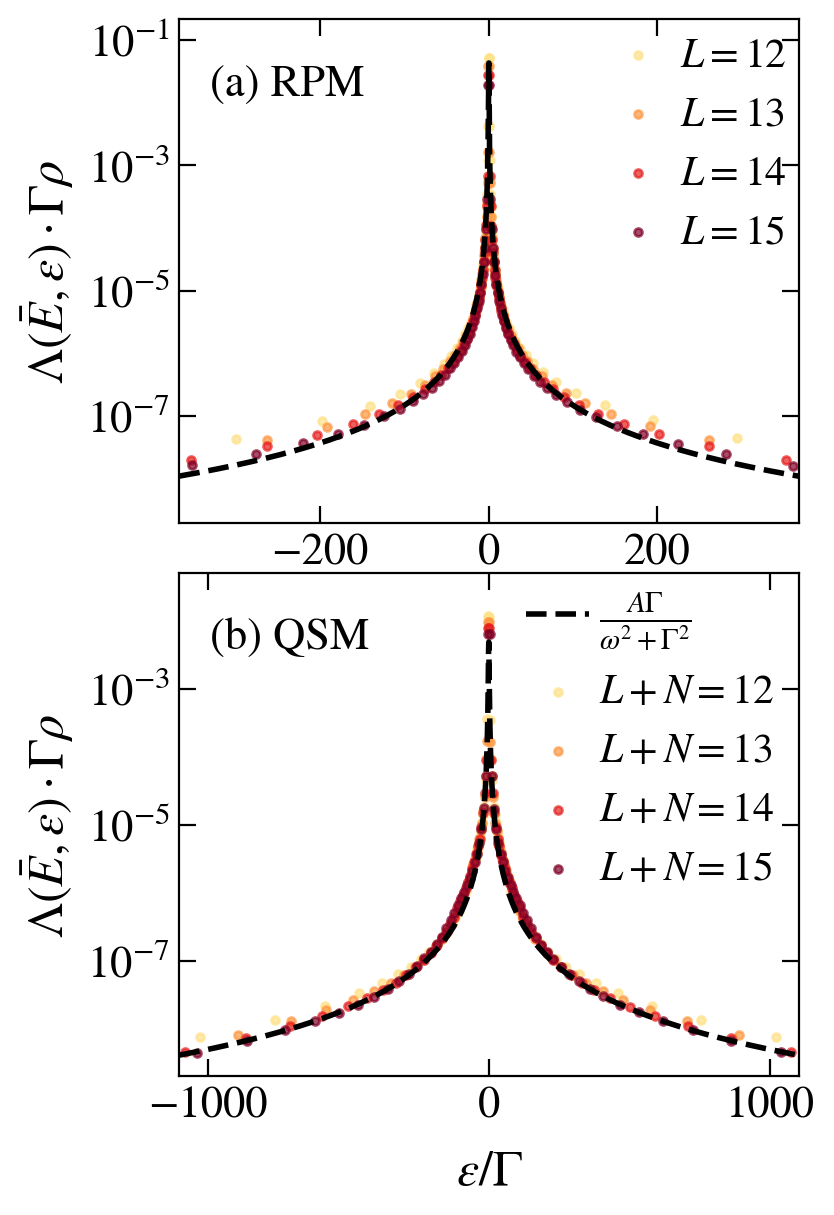

In [82]:
colors_ls_cyc = itertools.cycle(colors_ls)
from matplotlib.ticker import MaxNLocator

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM)

sizes = np.arange(12, 16, 1)

DIM = 1
fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,7), dpi = 200, sharex=False, sharey=False )


def lorenz(x, A, G):
    return A / G / np.pi / ( (x / G)**2 + 1)# / (np.exp(-x**2 / (2*sig**2) ) /np.sqrt(2*np.pi*sig**2))
    # return A / np.sqrt(2*np.pi*sig**2) * np.exp(-x**2 / (2*sig**2))

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.2, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])


L = 15
eps = 0.5
gamma_c = 2


gx = 1.6

dim = 1#2**L

gammas = np.arange(0.6, 2.51, 0.2)

for ii, L in enumerate(sizes):
    dim = 2**L
    col = s_m.to_rgba(L)
    num = min([100, dim//50])
    name = prefix + 'NewBasis/ParticipationRatio/' + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    if exists(name):
        with h5py.File(name, "r") as file:
            dE = np.mean(np.array(file.get('dE')))
            E0 = np.mean(np.array(file.get('E0')))
            energy_density = np.array(file.get('energy_density'))
            energy_density = (energy_density[1:] + energy_density[:-1]) / 2.
            # energy_density = -2*(energy_density-0.5)
            # energy_density = 2*(0.5 - energy_density)
            energy_density = ( (energy_density) * dE + E0)
            # energy_density = (E0 + dE/2) - ( (energy_density) * dE + E0)
            # ldos = np.exp( np.mean(np.log(np.array(file.get('LDOS'))), axis=1) )
            ldos = ( np.mean((np.array(file.get('LDOS'))), axis=1) )
            # ldos = np.array(file.get('LDOS'))[:,num//2]
            # print(L, gx, np.sum(ldos))
            
            sig = np.sqrt(1 + dim**(1.0 - gx))
            # DOS = dim / np.sqrt(2*np.pi*sig**2) * np.exp(-(energy_density)**2 / (2*sig**2))
            DOS = np.array(file.get('DOS'))
            HSnorm = dim+1
            G = 2 * np.pi * dim**(-gx)* HSnorm * DOS/(dim-1.0) # if gx >= 1 else DOS * sig * HSnorm
            
            xx = energy_density / G# * np.sqrt(dim)
            yy = ldos * G# * DOS # / G
            
            axis[0].scatter( xx, yy, color=col, label=r"$L=%d$"%L, s=8, alpha=0.7)
            # axis.fill_between(xx, yy, [0]*xx.size, color=col, label=r"$L=%d$"%L, alpha=0.5)
            # energy_density = np.array(file.get('energy_density2'))
            # energy_density = (energy_density[1:] + energy_density[:-1]) / 2.
            # # energy_density = -2*(energy_density-0.5)
            # energy_density = 2*(0.5 - energy_density)
            # # energy_density = -(energy_density * dE + E0)
            # # ldos = np.exp( np.mean(np.log(np.array(file.get('LDOS2'))), axis=1) )
            # ldos = ( np.mean((np.array(file.get('LDOS2'))), axis=1) )
            # axis.plot( energy_density, ldos, color=col, label=r"$L=%d$"%L_total)
            
            # pars, pconv= fit(lorenz,
            #         xdata = xx,
            #         ydata = yy,
            #         maxfev = 20000)
            
            # # print("A=", pars[0], "G=", pars[-1], "sig/sig_pred=", pars[-2] / np.sqrt(1 + dim**(1-gx)))
            # z = np.linspace(min(xx), max(xx), 1000)
            
            # # sig = np.sqrt(1 + dim**(1-gx))
            # # DOS = dim / np.sqrt(2*np.pi*sig**2) * np.exp(-z**2 / (2*sig**2))
            # # G = np.pi * dim**(-gx) * DOS
            # axis[iig].plot(z, lorenz(z, *pars), color=col, ls='--', lw=2, alpha=0.6)
            # axis[iig].set_ylim(min(yy), max(yy))
    else:
        print(name)

# pars, pconv= fit(lorenz,
#         xdata = xx[xx.size//2 - 10 : xx.size//2 + 10],
#         ydata = yy[xx.size//2 - 10 : xx.size//2 + 10],
#         maxfev = 20000)

# # print("A=", pars[0], "G=", pars[-1], "sig/sig_pred=", pars[-2] / np.sqrt(1 + dim**(1-gx)))
# z = np.linspace(min(xx), max(xx), int(1e6) )

# # sig = np.sqrt(1 + dim**(1-gx))
# # DOS = dim / np.sqrt(2*np.pi*sig**2) * np.exp(-z**2 / (2*sig**2))
# # G = np.pi * dim**(-gx) * DOS
# axis[0].plot(z, lorenz(z, *pars), color='k', ls='--', lw=2, alpha=0.6)

# z = np.linspace(-1, 1, 100000)
# G = 1e-4
# yy = 25 * G / ( z**2 + G**2 )
# axis[0].plot(z, yy, ls='--', color='k', lw=2, alpha=1, label=r"$\frac{A\Gamma}{\omega^2+\Gamma^2}$")
# axis.plot(np.nan, np.nan, ls='--', color='k', label=r"$\frac{A}{(\omega/\Gamma)^2+1}e^{-\frac{E^2}{(2\sigma^2)}}$")

fig_help.set_plot_elements(axis[0], ylabel=r"$\Lambda(\bar{E},\epsilon)\cdot\Gamma\rho$", xlabel=r"", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_legend(axis[0], fontsize=15, loc='upper right', anchor=(1.04, 1.04), ncol=1)
# axis[0].set_xlim(-0.165, 0.165)
# axis[0].set_ylim(2e-2, None)
axis[0].set_xlim(min(xx)/100, max(xx)/100)


L_total=14

J=1
alfa=0.88
h=1.0
w=0.5
zeta=0.2
N=3
gamma=1.0
ini_ave=0
L = L_total - N

scaled_disorder = 0

def info_rawQS(L, N, J, gamma, zeta, alfa, h, w, ini_ave = 0, use_old = False, scaled_disorder = False):
    wname = "W'" if scaled_disorder else 'w'
    arr = [J, gamma, zeta, alfa, h, w] if np.abs(alfa - 1.0) > 1e-10 else [J, gamma, alfa, h, w]
    names = ['J', 'g', 'zeta', 'alfa', 'h', wname] if np.abs(alfa - 1.0) > 1e-10 else ['J', 'g', 'alfa', 'h', wname]
    info = "_L=%d,N=%d"%(L,N)
    for i, var in enumerate(arr):
        n = order_of_magnitude2(var) if use_old else order_of_magnitude(var)
        info += str(",%s={:.%df}"%(names[i], n)).format(round(var, n))
    if ini_ave: info += ",ini_ave"
    return info

def infoQS(L, N, J, gamma, zeta, alfa, h, w, ini_ave = 0, use_old = False, scaled_disorder = False, ext = '.dat'):
    return info_rawQS(L, N, J, gamma, zeta, alfa, h, w, ini_ave, use_old, scaled_disorder) + ext

# sizes = np.arange(12, 16, 1)

for L_total in sizes:
    col = s_m.to_rgba(L_total)
    L = L_total - N
    dim = 2**L_total
    num = min([100, dim//50])
    name = "../../QuantumSun/results/" + 'NewBasis/ParticipationRatio/' + infoQS(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ini_ave=ini_ave, ext='.hdf5', scaled_disorder=scaled_disorder)
    if exists(name):
        with h5py.File(name, "r") as file:
            try:
                dE = np.mean(np.array(file.get('dE')))
                E0 = np.mean(np.array(file.get('E0')))
                energy_density = np.array(file.get('energy_density'))
                energy_density = (energy_density[1:] + energy_density[:-1]) / 2.
                # energy_density = -2*(energy_density-0.5)
                # energy_density = 2*(0.5 - energy_density)
                # energy_density = (E0 + dE/2) - ( (energy_density) * dE + E0)
                energy_density = ( (energy_density) * dE + E0)
                
                ldos = ( np.mean((np.array(file.get('LDOS'))), axis=1) )
                # ldos = np.exp( np.mean(np.log(np.array(file.get('LDOS'))), axis=1) )
                # ldos = np.array(file.get('LDOS'))[:,num//2]
                
                sigma = 0.5 * np.sqrt(L_total)
                # DOS = dim / np.sqrt(2*np.pi*sigma) * np.exp(-energy_density**2 / (2*sigma**2))
                DOS = np.array(file.get('DOS'))
                G = 2 * np.pi * (alfa)**(2*L) / 8 * DOS/dim * 1/8
                xx = energy_density / G# * np.sqrt(dim)
                yy = ldos * G# * DOS# / G
                axis[1].scatter( xx, yy, color=col, label=r"$L+N=%d$"%L_total, s=8, alpha=0.7)
                
                # pars, pconv= fit(lorenz,
                #         xdata = energy_density,#[ldos < 1e-2],
                #         ydata = ldos,#[ldos < 1e-2],
                #         maxfev = 20000)
                # z = np.linspace(-5, 5, 1000)
                # axis[ii].plot(z, lorenz(z, *pars), color=col, ls='--', lw=2, alpha=0.6)
            except IndexError:
                print(name)
    else:
        print(name)
        
        
z = np.linspace(min(xx), max(xx), int(5e5) )
G = 0.0001
yy = 15 * G / ( z**2 + G**2 )
axis[0].plot(z, yy, ls='--', color='k', lw=2, alpha=1, label=r"$\frac{A\Gamma}{\omega^2+\Gamma^2}$")

G = 1
yy = 0.005 * G / ( z**2 + G**2 )
axis[1].plot(z, yy, ls='--', color='k', lw=2, alpha=1, label=r"$\frac{A\Gamma}{\omega^2+\Gamma^2}$")

fig_help.set_plot_elements(axis[1], ylabel=r"$\Lambda(\bar{E},\epsilon)\cdot\Gamma\rho$", xlabel=r"$\varepsilon/\Gamma$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_legend(axis[1], fontsize=15, loc='upper right', anchor=(1.02, 1.04), ncol=1)

# axis[1].set_xlim(-0.27, 0.27)
axis[0].set_xlim(min(xx)/600, max(xx)/600)
axis[1].set_xlim(min(xx)/200, max(xx)/200)
axis[0].set_ylim(2e-9, None)
axis[1].set_ylim(2e-9, None)




axis[0].annotate(r"(a) RPM", fontsize=16, xy=(0.05, 0.85), xycoords='axes fraction')
axis[1].annotate(r"(b) QSM", fontsize=16, xy=(0.05, 0.85), xycoords='axes fraction')
fig.subplots_adjust(wspace = 0.2, hspace=0.1)

fig.savefig("PLOTS_FADING/BEYOND_RMT/Fig_ldos.pdf", bbox_inches = 'tight', pad_inches=0.02)

In [75]:

for L in np.arange(7, 19, 1):
    print(L, 2**L, 536870912/2**L)

7 128 4194304.0
8 256 2097152.0
9 512 1048576.0
10 1024 524288.0
11 2048 262144.0
12 4096 131072.0
13 8192 65536.0
14 16384 32768.0
15 32768 16384.0
16 65536 8192.0
17 131072 4096.0
18 262144 2048.0
